In [233]:
import numpy as np
import matplotlib.pyplot as plt 
import time
import os
from itertools import product

In [234]:
#helper functions

def hermitize(M):
    """hermitizes Matrix M into hermitian matrix s.t. H = (M + M^dagger)/2

    Args:
        M (np.ndarray): input matrix

    Returns:
        np.ndarray: hermitan matrix
    """
    return 0.5 * (M + M.conj().T)

def vec(M): 
    """flattens a matrix to a vector with column major

    Args:
        M (np.ndarray): matrix

    Returns:
        np.ndarray: vector
    """
    return M.reshape((-1,), order = "F")

def mat(v, d): 
    """generates matrix out of vector that was flattened with column major (inverse function to vec(M))

    Args:
        v (np.ndarray): vector
        d (int): dimension

    Returns:
        np.ndarray: matrix
    """
    return v.reshape((d,d), order ="F")

def tensor_product(Matrices): 
    """builds the tensorprodict of given matrices

    Args:
        Matrices (list[np.ndarray]): list of matrices

    Returns:
        np.ndarray: tensorproduct of the given matrices
    """
    tensorproduct = Matrices[0]
    for M in Matrices[1:]:
        tensorproduct = np.kron(tensorproduct, M)
    return tensorproduct

def ket_to_vec(ket_bitstring): 
    """takes the bitstring of a ket (or bra) and builds a vector from it 

    Args:
        ket_bitstring (str): string of as ket like |string> 

    Returns:
        np.ndarray: column vector representing the ket
    """
    N = len(ket_bitstring)
    d = 2**N
    vec = np.zeros((d, 1), dtype = complex)

    index = int(ket_bitstring, 2)
    vec[index, 0] = 1.0

    return vec

def density_from_state(state):
    """buiilds the density matrix of a pure state vector like rho = |psi><psi|

    Args:
        state (np.ndarray): pure state vector

    Returns:
        np.ndarray: density matrix
    """
    state = np.asarray(state, dtype=complex).reshape(-1, 1)
    density_matrix = state @ state.conj().T
    return density_matrix

In [235]:
#build matrices

def build_bm(E): 
    """generates basis bm out of the POVM-effects E

    Args:
        E (np.ndarray): POVM effects

    Returns:
        np.ndarray: basis matrix bm with B_k als colums (vectorized) 
    """
    M = np.column_stack([vec(Ej) for Ej in E])      #M is (d^2, n) -> matrix with vectorized POVM effects as columns
    U,S,V = np.linalg.svd(M, full_matrices=False)       #SVD, full_matrices=False, bc doesnt matter if true of false but its less computation
    D = np.sum(S > 1e-12)           #D is relevant number of dimensions with redundance removed 
    bm = U[:, :D]           #first D columns of U (they are orthonormal)

    return bm       #dim (d^2, D)

def build_R(E, bm):
    """generates the coefficient- matrix R with E_j as column j s.t. p = R @ vec(rho) gives p_j = Tr(E_j * rho) -- bm is used to reduce E_j

    Args:
        E (np.ndarray): list of POVM-elements E_j 
        bm(np.ndarray): basis matrix B with B_k as columns (vectorized)

    Returns:
        np.ndarray: coefficient matrix R 
    """
    n = len(E)
    D = bm.shape[1]
    R = np.zeros((n, D), dtype = complex)

    for j, Ej in enumerate(E):
        R[j, :] = (bm.conj().T @ vec(Ej)).conj()
    
    return R        #dim (n,D)

def build_L_MP(R): 
    """calculates L_MP via Moore Penrose for the initial coefficients
        Moore-Penrose: L_MP = R@(R.T@R)^-1

    Args:
        R (np.ndarray): "right" coefficient matrix

    Returns:
        np.ndarray: "left" coefficient matrix via Moore-Penrose
    """
    L = R @ np.linalg.inv(R.conj().T @ R)
    return L

def build_L_opt(R, p):
    """calculates L_opt via the optimized variant introduced in the paper 
        L_opt = P^-1 @ R @(R.T @ P^-1 @ R)^-1 

    Args:
        R (np.ndarray): "right" coefficient matrix
        p (np.ndarray): probability vector

    Returns:
        np.ndarray: "left" coefficient matrix via optimized method
    """

    
    P_inv_R =  R / p[:, None]
    L = P_inv_R @ np.linalg.inv(R.conj().T @ P_inv_R)
    return L

In [236]:
#build and calculate coefficients

def build_o(O, bm):
    """builds o, the representation of the observable O in basis bm

    Args:
        O (np.ndarray): Observable
        bm (np.ndarray): basis matrix B with B_k as columns (vectorized)

    Returns:
        np.ndarray: representation of O in basis o
    """
    o = bm.conj().T @vec(O)
    return o

def build_rhoflat(rho_params, bm): 
    """generates the vector rho_flat in subspace D 

    Args:
        rho_params (np.ndarray): real parameters to construct the density matrix rho
        bm(np.ndarray): basis matrix B with B_k as columns (vectorized)

    Raises:
        ValueError: if the length of the parameters is not d^2

    Returns:
        tuple(np.ndarray, np.ndarray): matrix rho for sanity checks and later implementations, vector rho_flat in subspace D 
    """
    d = int(np.sqrt(rho_params.size))
    if d*d != rho_params.size: 
        raise ValueError("length of rho_params must be d^2")
    
    Param_mat = mat(rho_params, d)
    L_diag = np.diag(np.diag(Param_mat))        #2 times diag to get matrix with diagonal
    L_lower_real = np.tril(Param_mat, k=-1)     
    L_lower_imag = np.tril(Param_mat.T, k=-1)
    L = L_diag + L_lower_real + 1j * L_lower_imag   #lower triangular matrix with real diagonal and imag lower triag. upper triag is 0 
    LL = L @ L.conj().T     #cholesky without restriction of positive diagonal elements

    rho = LL/np.trace(LL)       #is already hermitan but maybe another hermitization needed to erase small imag parts? 
    rho_vec = vec(rho)
    rho_flat = bm.conj().T @ rho_vec        #projection from d^2 into subspace D 

    return rho, rho_flat         #rho for sanity checks and maybe needed for qutrits? also for other calcs (fidelity, eigenvalues,...)

def calc_prob(R, rho_params, bm):
    """calculates the probability vector p with entries p_j at row j with p = R*rho_flat (p_j = Tr(E_j * rho))

    Args:
        R (np.ndarray): coefficient matrix 
        rho_params (np.ndarray): real parameters to construct the density matrix rho
        bm(np.ndarray): basis matrix B with B_k as columns (vectorized)

    Returns:
        tuple(np.ndarray, np.ndarray): matrix rho for sanity checks and later implementations, probability vector p
    """
    rho, rho_flat = build_rhoflat(rho_params, bm)
    p = np.real(R @ rho_flat)       #np.real to eliminate possible small imaginary part 
    p_safe = np.maximum(p, 1e-12)
    p_normalized = p_safe / np.sum(p_safe)

    return rho, p_normalized       #p has dim (n)

def calc_prob_from_matrix(R, bm, rho):
    """calculates probability vector p from a matrix rho

    Args:
        R (_type_): _description_
        bm (_type_): _description_
        rho (_type_): _description_

    Returns:
        _type_: probability vector p 
    """
    rho_flat = bm.conj().T @ vec(rho)

    p = np.real(R @ rho_flat)
    p_safe = np.maximum(p, 1e-12)
    p_normalized = p_safe / np.sum(p_safe)

    return p_normalized


def calc_coefficients(L, o):
    """calculates the coefficients 

    Args:
        L (np.ndarray): "left" coefficient matrix
        o (np.ndarray): observable in basis bm

    Returns:
        np.ndarray: the calculated coefficients
    """
    c =  L @ o 
    return c



In [237]:
def simulate_frequencis_from_probabilities(p, K, seed = None):
    """simulates frequencies f from probabilities p 

    Args:
        p (_type_): probability vector 
        K (_type_): number of measurements
        seed (_type_, optional): seed for reproducing measurements. Defaults to None.

    Returns:
        _type_: frequency vector f
    """
    rng = np.random.default_rng(seed)

    k = rng.multinomial(K, p)       #k are the number of occurences
    f = k / K

    return f

In [238]:
#calculations

def calc_negative_variance_fixed_c(R, rho_params, c, bm): 
    """calculates the negative variance Var = -E(X^2) + E(X)^2

    Args:
        R (np.ndarray): coefficient matrix 
        rho_params (np.ndarray): real parameters to construct the density matrix rho
        c (np.ndarray): fixed estimator input coefficients 
        bm(np.ndarray): basis matrix B with B_k as columns (vectorized)

    Returns:
        float: negative variance       
    """
    _, p = calc_prob(R, rho_params, bm)
    c2 = np.conj(c) * c

    var_neg =  np.real(- np.dot(p, c2)  + np.abs(np.dot(p, c))**2 )

    return var_neg

def calc_negative_variance_var_c(R, rho_params, O,  bm): 
    """calculates the negative variance Var = -E(X^2) + E(X)^2

    Args:
        R (np.ndarray): coefficient matrix 
        rho_params (np.ndarray): real parameters to construct the density matrix rho
        c (np.ndarray): fixed estimator input coefficients 
        bm(np.ndarray): basis matrix B with B_k as columns (vectorized)

    Returns:
        float: negative variance       
    """
    o = build_o(O, bm)
    _, p = calc_prob(R, rho_params, bm)
    L_opt = build_L_opt(R, p)
    c = calc_coefficients(L_opt, o)

    c2 = np.conj(c) * c
    var_neg =  np.real(- np.dot(p, c2)  + np.abs(np.dot(p, c))**2 )

    return var_neg


def calc_grad(f, rho_params, h = 10**-6):
    """calculates gradient of function f via central difference method

    Args:
        f (function): differentiated function (callable)    use wrapper in main bc negative var dunctions output will be float not function
        rho_params (np.ndarray): real parameters to construct the density matrix rho
        h (float, optional): stepsize. Defaults to 10**-6.

    Returns:
        np.ndarray: gradient of function f 
    """
    grad = np.zeros_like(rho_params)

    for i in range(rho_params.size):
        rho_params_plus = rho_params.copy()
        rho_params_minus = rho_params.copy()
        rho_params_plus[i] += h
        rho_params_minus[i] -= h
        grad[i] = (f(rho_params_plus) - f(rho_params_minus)) / (2*h)         
    
    return grad

def calc_fidelities_by_coeffs(f0, c):
    """calculates the fidelities from the coefficients, the frequencies and the variances

    Args:
        p0 (_type_): probabilities depending in theta
        c (_type_): coefficients depending on phi 
        var (_type_): variances depending on phi
    Returns:
        _type_: list of Fidelities 
    """
    F_list = np.real(c@f0)

    return F_list

def calc_fidelity_errors(var, K):
    """calculates the error of the Fidelity F

    Args:
        var (_type_): variance 
        K (_type_): number of measurements

    Returns:
        _type_: error of Fidelity 
    """
    var = np.asarray(var, dtype=float)
    var = np.maximum(var, 0.0)
    F_error = np.sqrt(var/K)

    return F_error


def calc_var_from_f_and_c(f, c): 
    """generic calculation of the variance (not worst case variance)

    Args:
        f (_type_): _description_
        c (_type_): _description_

    Returns:
        _type_: _description_
    """
    c2 = np.conj(c) * c
    var =  np.real(np.dot(f, c2)  - np.abs(np.dot(f, c))**2 )

    return var

In [239]:
#gradient descent

def gradient_descent_changing_c(R, O, bm, cycles = 50, eps_restart = 2e-3, max_steps = 100, learnrate = 0.25, h = 2e-6, seed = 0):  
    """does the gradient descent many times to find the maximum variance and the corresponding desity matrix rho
        scipy.optimize.minimize would be a better way for more Qubits 

    Args:
        R (np.ndarray): coefficient matrix
        O (np.ndarray): Observable
        bm (np.ndarray): basis matrix B with B_k as columns (vectorized)
        cycles (int, optional): number of restarts of the gradient descent. Defaults to 50.
        eps_restart (float, optional): number to modify restart perturbarion. Defaults to 2e-3.
        max_steps (int, optional): number of maximum gradient descent steps per restart. Defaults to 100.
        learnrate (float, optional): learnrate (eta) - gradient descent specific inout. Defines how fast the gradient descent should converge. 
                                     Must not be too big or too small in order for gradient descent t o work. Defaults to 0.25.
        h (float, optional): stepsize for gradient calculation. Defaults to 2e-6.
        seed (int, optional): seed for rng, to make it reproducable. Defaults to 0.

    Returns:
        tuple[float, np.ndarray, np.ndarray]: maximum variance found, density matrix that produces maximum variance, best c, the history of the best variance in each itertion for visualization
    """
    d2 = bm.shape[0]            
    rho_params_dim = d2

    #initial coefficients
    o = build_o(O, bm)
    L_MP = build_L_MP(R)
    c = calc_coefficients(L_MP, o)

    def neg_var(rho_params):
            """to make the function only dependant on the variable parameters -> fix R, c, bm
                now inside to use updated c 

            Args:
                rho_params (np.ndarrays): real parameters to construct the density matrix rho
            Returns:
                float: negative variance
            """
            return calc_negative_variance_var_c(R, rho_params, O, bm)
    
    #bounds
    lb = -np.ones(rho_params_dim, dtype = float)
    ub = +np.ones(rho_params_dim, dtype = float)

    best_rho_params = np.ones(rho_params_dim, dtype = float) /float(rho_params_dim)     
    best_neg_var = calc_negative_variance_fixed_c(R, best_rho_params, c, bm)
    history_best_var = [-best_neg_var]
    best_c = c.copy()
    
    rng = np.random.default_rng(seed)
    restart_perturbation = np.ones(rho_params_dim, dtype = float)
    
    #restart loop 
    for _ in range(cycles):   
        start = best_rho_params + eps_restart * rng.random(rho_params_dim) * restart_perturbation
        start = np.clip(start, lb, ub)

        rho_params = start.copy()
        local_learnrate = learnrate

        current_neg_var = calc_negative_variance_var_c(R, rho_params, O, bm)

        #gradient descent
        for _ in range(max_steps): 
            grad = calc_grad(neg_var, rho_params, h)
            new_rho_params = rho_params - local_learnrate * grad
            new_rho_params = np.clip(new_rho_params, lb, ub)

            new_neg_var = neg_var(new_rho_params)

            if new_neg_var <= current_neg_var: 
                rho_params = new_rho_params
                current_neg_var = new_neg_var

                _, p = calc_prob(R, rho_params, bm)
                L_opt = build_L_opt(R, p)
                c_new = calc_coefficients(L_opt, o)

                if current_neg_var < best_neg_var: 
                    best_neg_var = current_neg_var
                    best_rho_params = rho_params.copy()
                    best_c = c_new.copy()
                    restart_perturbation = np.abs(start - rho_params) + 1e-12       #1e-12 in case start * rho params 

            else: 
                local_learnrate *= 0.5
                if local_learnrate < 1e-6: 
                    break

            
        
        history_best_var.append(-best_neg_var)

    var_max = -best_neg_var
    best_rho, _ = build_rhoflat(best_rho_params, bm)

    return var_max, best_rho, best_c, history_best_var 

def gradient_descent_fixed_c(R, c, bm, cycles = 50, eps_restart = 2e-3, max_steps = 100, learnrate = 0.25, h = 2e-6, seed = 0):  
    """does the gradient descent many times to find the maximum variance and the corresponding desity matrix rho
        scipy.optimize.minimize would be a better way for more Qubits 

    Args:
        R (np.ndarray): coefficient matrix
        c (np.ndarray): fixed estimator input coefficients
        bm (np.ndarray): basis matrix B with B_k as columns (vectorized)
        cycles (int, optional): number of restarts of the gradient descent. Defaults to 50.
        eps_restart (float, optional): number to modify restart perturbarion. Defaults to 2e-3.
        max_steps (int, optional): number of maximum gradient descent steps per restart. Defaults to 100.
        learnrate (float, optional): learnrate (eta) - gradient descent specific inout. Defines how fast the gradient descent should converge. 
                                     Must not be too big or too small in order for gradient descent t o work. Defaults to 0.25.
        h (float, optional): stepsize for gradient calculation. Defaults to 2e-6.
        seed (int, optional): seed for rng, to make it reproducable. Defaults to 0.

    Returns:
        tuple[float, np.ndarray, np.ndarray]: maximum variance found, density matrix that produces maximum variance, the history of the best variance in each itertion for visualization
    """
    d2 = bm.shape[0]            
    rho_params_dim = d2
    
    def neg_var(rho_params):
        """to make the function only dependant on the variable parameters -> fix R, c, bm

        Args:
            rho_params (np.ndarrays): real parameters to construct the density matrix rho
        Returns:
            float: negative variance
        """
        return calc_negative_variance_fixed_c(R, rho_params, c, bm)
    
    #bounds
    lb = -np.ones(rho_params_dim, dtype = float)
    ub = +np.ones(rho_params_dim, dtype = float)

    best_rho_params = np.ones(rho_params_dim, dtype = float) /float(rho_params_dim)     
    best_neg_var = neg_var(best_rho_params)
    history_best_var = [-best_neg_var]
    
    rng = np.random.default_rng(seed)
    restart_perturbation = np.ones(rho_params_dim, dtype = float)
    
    #restart loop 
    for _ in range(cycles): 
        start = best_rho_params + eps_restart * rng.random(rho_params_dim) * restart_perturbation
        start = np.clip(start, lb, ub)

        rho_params = start.copy()
        local_learnrate = learnrate

        #gradient descent
        for _ in range(max_steps): 
            grad = calc_grad(neg_var, rho_params, h)
            new_rho_params = rho_params - local_learnrate * grad
            new_rho_params = np.clip(new_rho_params, lb, ub)

            if neg_var(new_rho_params) <= neg_var(rho_params): 
                rho_params = new_rho_params
            else: 
                local_learnrate *= 0.5
                if local_learnrate < 1e-6: 
                    break

        neg_var_cycle = neg_var(rho_params)

        if neg_var_cycle < best_neg_var: 
            best_neg_var = neg_var_cycle
            best_rho_params = rho_params
            restart_perturbation = np.abs(start - rho_params) + 1e-12       #1e-12 in case start * rho params 
        history_best_var.append(-best_neg_var)

    var_max = -best_neg_var
    best_rho, _ = build_rhoflat(best_rho_params, bm)

    return var_max, best_rho, history_best_var  

In [240]:
#build POVM Effects

def Pauli_matrices():
    """generates Pauli - matrices

    Returns:
        tuple[np.ndarray]: Pauli matrices: X, Y, Z
    """
    X = np.array([[0, 1], [1,0]], dtype = complex)
    Y = np.array([[0, -1j], [1j, 0]], dtype = complex)
    Z = np.array([[1, 0], [0, -1]], dtype = complex)
    return X, Y, Z

def build_E_from_Paulis(): 
    """Builds the POVM-Effekts E_j 

    Returns:
        list[np.ndarray]: List E with POVM effects E_j
    """
    X, Y, Z = Pauli_matrices()
    I = np.eye(2, dtype = complex)

    P_xp = 0.5 * (I+X)
    P_xm = 0.5 * (I-X)
    P_yp = 0.5 * (I+Y) 
    P_ym = 0.5 * (I-Y)
    P_zp = 0.5 * (I+Z)
    P_zm = 0.5 * (I-Z)

    return [(1/3)*P for P in [P_xp, P_xm, P_yp, P_ym, P_zp, P_zm]]          #n elements with dim (d,d)

def build_Ndim_E(N):
    """Build N-qubit POVM effects from tensorproduct of 1-Qubit POVM-effects (Pauli)

    Args:
        N (int): number of qubits

    Returns:
        list[np.ndarray]: list of N-qubits POVM-effects
    """
    E_local = build_E_from_Paulis()
    E_global = []

    for index_tuple in product(range(len(E_local)), repeat=N):          #cartesian product
        factors = [E_local[i] for i in index_tuple]                     #(2,4,0) -> [E[2], E[4], E[0]]
        E_global.append(tensor_product(factors))       
    return E_global  

In [241]:
#GHZ Test-case

def build_GHZ_state(N, theta): 
    """builds the GHZ-like state with N qubits and the phase theta

    Args:
        N (int): number of qubits
        theta (float): phase parameter

    Returns:
        np.ndarray: the state vector |psi_theta>
    """
    ket_zeros = ket_to_vec("0" *N)
    ket_ones = ket_to_vec("1"*N)

    psi = (ket_zeros + np.exp(1j * theta) * ket_ones) / np.sqrt(2.0)
    return psi

def build_GHZ_projector(N, theta): 
    psi = build_GHZ_state(N, theta)
    O = psi @ psi.conj().T 
    return O, psi

In [242]:
#old but mybe useful code 
#find theta value that maximizes the variance

def find_theta_max_var(N, theta_values, max_outer_steps =15, cycles = 20, learnrate = 0.0001, seed = 1):
    """finds theta value that maximizes variance

    Args:
        N (_type_): _description_
        theta_values (_type_): _description_
        max_outer_steps (int, optional): _description_. Defaults to 15.
        cycles (int, optional): _description_. Defaults to 20.
        learnrate (float, optional): _description_. Defaults to 0.0001.
        seed (int, optional): _description_. Defaults to 1.

    Returns:
        _type_: _description_
    """
    E = build_Ndim_E(N)         #list of POVM effects
    bm = build_bm(E)            #basis matrix                  
    R = build_R(E, bm)          #coefficient matrix R 

    max_vars = np.zeros(len(theta_values), dtype=float)

    best_theta = None
    best_var = 0
    best_rho = None
    best_c = None

    for k, theta in enumerate(theta_values):
        O, psi = build_GHZ_projector(N, theta)

        tbest_var = 0
        tbest_rho = None
        tbest_c = None

        for s in range(max_outer_steps):
            cur_var, cur_rho, cur_c, history = gradient_descent_changing_c(R, O, bm, cycles = cycles, learnrate= learnrate,  seed = seed + s )
            if cur_var >= tbest_var:
                tbest_var = cur_var
                tbest_rho = cur_rho
                tbest_c = cur_c

        max_vars[k] = tbest_var
        
        if tbest_var >= best_var:
            best_theta = theta
            best_var = tbest_var
            best_rho = tbest_rho
            best_c = tbest_c

    return max_vars, best_theta, best_var, best_rho, best_c

#visualisation

def plot_maxvar_vs_theta(theta_values, max_vars):
    theta_values = theta_values #/ np.pi
    plt.figure(figsize=(7,4))
    plt.plot(theta_values, max_vars, marker="o")
    plt.xlabel("theta in rad")
    plt.ylabel("maximal variance")
    plt.title("maximal variance vs theta")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def call_find_theta_max_var(N, theta_values, max_outer_steps, cycles, learnrate = 0.0001, seed =1):
    """calls the find theta max var function

    Args:
        N (_type_): _description_
        theta_values (_type_): _description_
        max_outer_steps (_type_): _description_
        cycles (_type_): _description_
        learnrate (float, optional): _description_. Defaults to 0.0001.
        seed (int, optional): _description_. Defaults to 1.
    """
    max_vars, best_theta, best_var, best_rho, best_c = find_theta_max_var(N, theta_values, max_outer_steps, cycles, learnrate, seed)

    print("Maximum Variance = ", best_var)
    #print("Best rho = \n", best_rho)
    #print("Best coefficients = \n", best_c)
    print(f"Trace of rho: {np.real(np.trace(best_rho))}")
    print(f"Smallest eigenvalue of rho: {np.min(np.linalg.eigvalsh(best_rho))}")
    print("Best theta = \n", best_theta)

    plot_maxvar_vs_theta(theta_values, max_vars)



#estimate theta generic
def estimate_theta(rho0, N, theta_values, max_outer_steps = 5, cycles = 20, learnrate = 0.0001, seed = 1):
    """Estimates theta from input state rho0 using the optimized coefficients

    Args:
        rho0 (np.ndarray): input state as density matrix
        N (_type_): number of qubits
        theta_values (_type_): candidates for theta (phi)
        max_outer_steps (int, optional): _description_. Defaults to 5.
        cycles (int, optional): _description_. Defaults to 20.
        learnrate (float, optional): _description_. Defaults to 0.0001.
        seed (int, optional): _description_. Defaults to 1.

    Returns:
        _type_: estimated theta, Fidelities for each angle, worst dcase variances,  list of optimized coefficients
    """
    E = build_Ndim_E(N)
    bm = build_bm(E)
    R = build_R(E, bm)
    p0 = calc_prob_from_matrix(R, bm, rho0)

    F_list = np.zeros(len(theta_values), dtype = float)
    variances = np.zeros(len(theta_values), dtype = float)
    best_c = []

    for k, phi in enumerate(theta_values):      #phi are theta-candidates and theta0 iist the actual value
        O_phi, psi_phi = build_GHZ_projector(N, phi)

        run_best_var = 0 
        run_best_c_phi = None

        for s in range(max_outer_steps):
            cur_var, cur_rho, cur_c, history = gradient_descent_changing_c(R, O_phi, bm, cycles = cycles, learnrate= learnrate,  seed = seed + s )
            if cur_var >= run_best_var:
                run_best_var = cur_var
                run_best_c_phi = cur_c

        F = np.real(np.dot(p0, run_best_c_phi))

        F_list[k] = F
        variances[k] = run_best_var
        best_c.append(run_best_c_phi)

    index_best_theta = int(np.argmax(F_list))
    theta_est = theta_values[index_best_theta]

    return theta_est, F_list, variances, best_c 


def call_estimate_theta(N, real_theta, theta_values, max_outer_steps, cycles, learnrate = 0.0001, seed =1):
    """calls the estimate theta function

    Args:
        N (_type_): _description_
        real_theta (_type_): _description_
        theta_values (_type_): _description_
        max_outer_steps (_type_): _description_
        cycles (_type_): _description_
        learnrate (float, optional): _description_. Defaults to 0.0001.
        seed (int, optional): _description_. Defaults to 1.
    """
    rho0, psi0 = build_GHZ_projector(N, real_theta)

    theta_est, F_list, variances, best_c = estimate_theta(rho0, N, theta_values, max_outer_steps, cycles, learnrate, seed)

    
    print("True theta       =", real_theta)
    print("Estimated theta  =", theta_est)
    print("Best Fidelity    =", np.max(F_list))
    print("Trace rho0       =", np.trace(rho0))
    print("Smallest Eig rho0=", np.min(np.linalg.eigvalsh(rho0)))



In [243]:
#create a coeficient file for test purposes 

def create_coeff_file(filename, N, theta_values, max_outer_steps = 5, cycles = 20, max_gd_steps = 100, learnrate = 0.0001, seed = 1): 
    """creates the coefficient file

    Args:
        filename (_type_): _description_
        N (_type_): _description_
        theta_values (_type_): _description_
        max_outer_steps (int, optional): _description_. Defaults to 5.
        cycles (int, optional): _description_. Defaults to 20.
        learnrate (float, optional): _description_. Defaults to 0.0001.
        seed (int, optional): _description_. Defaults to 1.
    """
    E = build_Ndim_E(N)
    bm = build_bm(E)
    R = build_R(E, bm)

    theta_values = np.asarray(theta_values, dtype=float)

    n = len(E)

    c = np.zeros((len(theta_values), n), dtype=complex)
    var = np.zeros(len(theta_values), dtype=float)

    for k, phi in enumerate(theta_values):
        O_phi, phi_phi = build_GHZ_projector(N, phi)

        best_c_run = None
        best_var_run = 0

        for s in range(max_outer_steps):
            cur_var, cur_rho, cur_c, history = gradient_descent_changing_c(R, O_phi, bm, cycles = cycles, learnrate= learnrate,  max_steps = max_gd_steps, seed = seed + s )

            if cur_var >= best_var_run:
                best_var_run = cur_var
                best_c_run= cur_c

        c[k, :] = best_c_run
        var[k] = best_var_run

    np.savez(filename, N = N, theta_values = theta_values, coefficients = c, variances = var)
    

In [244]:
#load, sort and verify coefficient file

def load_coeff_file(coefficient_file):
    """loads the coefficients file

    Args:
        coefficient_file (_type_): file to be loadeed

    Returns:
        _type_: list of theta, list of c , list of var
    """
    data = np.load(coefficient_file)

    theta_values = np.asarray(data["theta_values"], dtype=float)
    c = np.asarray(data["coefficients"], dtype=complex)
    var = np.asarray(data["variances"], dtype=float)

    return theta_values, c, var

def sort_coeff_file(theta_values, c, var):
    """sorts the thatas, c and vars by the theta_values

    Args:
        theta_values (_type_): _description_
        c (_type_): _description_
        var (_type_): _description_

    Returns:
        _type_: sorted:  thetas, c , var
    """
    order = np.argsort(theta_values)

    theta_values = theta_values[order]
    c = c[order]
    var = var[order]

    return theta_values, c, var

def validate_coeff_file(theta_values, c, var, n_expected):
    """checks if the coefficients file is structured as needed

    Args:
        theta_values (_type_): _description_
        c (_type_): _description_
        var (_type_): _description_
        n_expected (_type_): _description_

    Raises:
        ValueError: _description_
        ValueError: _description_
        ValueError: _description_
        ValueError: _description_
        ValueError: _description_
    """
    if theta_values.ndim != 1: 
        raise ValueError("theta_values must be 1D array")
    
    if c.ndim != 2:
        raise ValueError("coefficients must be 2D array")

    if c.shape[0] != theta_values.size: 
        raise ValueError("coefficients must be equally long as theta_values")
    
    if c.shape[1] != n_expected: 
        raise ValueError("The shape of the coefficients is wrong")
    
    if var.shape[0] != theta_values.size: 
        raise ValueError("variances must be equally long as theta_values")


In [245]:
#estimate theta first from file or with additional gradient descent with optimal coefficients

def estimate_theta_between_values(rho0, N, theta_left, theta_right, F_min, f0 = None, K = None, measurement_seed = None,  max_refinement_steps = 30,  max_outer_steps = 5, cycles = 20, max_gd_steps = 100, learnrate = 0.0001, seed = 1):
    """Estimates theta from input state rho0 using the optimized coefficients

    Args:
        rho0 (np.ndarray): input state as density matrix
        N (_type_): number of qubits
        theta_left/right: theta values slightly above and below max theta that gets F_max
        F_min: threshhold for fidelity
        f0: frequencies 
        K: number of measurements
        max_refinement_steps: a max number of refinements to avoid crashing
        max_outer_steps (int, optional): _description_. Defaults to 5.
        cycles (int, optional): _description_. Defaults to 20.
        learnrate (float, optional): _description_. Defaults to 0.0001.
        seed (int, optional): _description_. Defaults to 1.

    Returns:
        _type_: best theta, best fidelity, best variance, best coefficients (all of the value with the best fidelity)
    """
    E = build_Ndim_E(N)
    bm = build_bm(E)
    R = build_R(E, bm)

    if f0 is None: 
        p0 = calc_prob_from_matrix(R, bm, rho0)

        if K is None: 
            raise ValueError("Input Value for f or K")
        
        f0 = simulate_frequencis_from_probabilities(p0, K, measurement_seed)

    #to make sure we know which value is smaller
    lower_theta = float(theta_left)
    upper_theta = float(theta_right)

    N_gd = 0

    if lower_theta > upper_theta:
        lower_theta, upper_theta = upper_theta, lower_theta

    def evaluate_phi(phi, seed):
        nonlocal N_gd
        
        O_phi, psi_phi = build_GHZ_projector(N, phi)

        run_best_var = 0 
        run_best_c_phi = None

        for s in range(max_outer_steps):
            N_gd += 1
            cur_var, cur_rho, cur_c, history = gradient_descent_changing_c(R, O_phi, bm, cycles = cycles, max_steps= max_gd_steps, learnrate= learnrate,  seed = seed + s )
            if cur_var >= run_best_var:
                run_best_var = cur_var
                run_best_c_phi = cur_c

        F = np.real(np.dot(f0, run_best_c_phi))
        if K is None: 
            F_err = None
        else:
            F_err = calc_fidelity_errors(run_best_var, K)
        return F, F_err, run_best_var, run_best_c_phi

    F_a, F_err_a, var_a, c_a = evaluate_phi(lower_theta, seed=1)
    F_b, F_err_b, var_b, c_b = evaluate_phi(upper_theta, seed= seed + 100)

    if F_a >= F_b:
        theta_best = lower_theta
        F_best = F_a
        F_err_best = F_err_a
        var_best = var_a
        c_best = c_a
    else:
        theta_best = upper_theta
        F_best = F_b
        F_err_best = F_err_b
        var_best = var_b
        c_best = c_b 

    step = 0

    while (F_best + F_err_best) < F_min and step < max_refinement_steps:
        mid_theta = 0.5 * (lower_theta + upper_theta)

        F_mid, F_err_mid, var_mid, c_mid = evaluate_phi(mid_theta, seed = 10 + step)

        if F_mid > F_best:
            theta_best = mid_theta
            F_best = F_mid
            F_err_best = F_err_mid
            var_best = var_mid
            c_best = c_mid

        if (F_mid+ F_err_mid) >= F_min:
            break

        if F_a >= F_b: 
            upper_theta = mid_theta
            F_b = F_mid
            F_err_b = F_err_mid
            var_b = var_mid
            c_b = c_mid
        else: 
            lower_theta = mid_theta
            F_a = F_mid
            F_err_a = F_err_mid
            var_a = var_mid
            c_a = c_mid

        step += 1

    return theta_best, F_best, F_err_best, var_best, c_best, N_gd

def find_theta_max_F(rho0, N, coefficient_file, F_min, K, measurement_seed = None, max_refinement_steps = 30, max_outer_steps = 5, cycles = 20, max_gd_steps = 100, learnrate = 0.0001, seed = 1):
    E = build_Ndim_E(N)
    bm = build_bm(E)
    R = build_R(E, bm)
    p0 = calc_prob_from_matrix(R, bm, rho0)
    f0 = simulate_frequencis_from_probabilities(p0, K, measurement_seed)
    n_expected = len(E)

    theta_values, c, var = load_coeff_file(coefficient_file)
    theta_values, c, var = sort_coeff_file(theta_values, c, var)
    validate_coeff_file(theta_values, c, var, n_expected)

    F_list = calc_fidelities_by_coeffs(f0, c)
    F_err_list = calc_fidelity_errors(var, K)

    N_iter = len(theta_values)
    N_gd = 0

    possible_theta_indices = np.where(F_list >= F_min)[0]

    if len(possible_theta_indices) > 0: 
        best_theta_index = possible_theta_indices[np.argmax(F_list[possible_theta_indices])]

        theta_best = theta_values[best_theta_index]
        F_best = F_list[best_theta_index]
        F_err_best = F_err_list[best_theta_index]
        var_best = var[best_theta_index]
        c_best = c[best_theta_index]

    
    else:
        best_file_index = int(np.argmax(F_list))

        m = len(theta_values)

        left_index = (best_file_index - 1) % m
        right_index = (best_file_index + 1) % m

        #to avoid duplicate endpoints
        if m > 1 and np.isclose(theta_values[-1] - theta_values[0], 2*np.pi):
            if best_file_index == 0: 
                left_index = m-2
            elif best_file_index == m-1: 
                best_file_index = 0
                left_index = m-2
                right_index = 1

        if F_list[left_index] >= F_list[right_index]:
            theta_left = float(theta_values[left_index])
            theta_right = float(theta_values[best_file_index])
        else: 
            theta_left = float(theta_values[best_file_index])
            theta_right = float(theta_values[right_index])

        if theta_right < theta_left:
            theta_right += (2*np.pi)
        
        theta_best, F_best, F_err_best,  var_best, c_best, N_gd_refine = estimate_theta_between_values(rho0, N, theta_left, theta_right, F_min, f0 = f0, K = K, measurement_seed=measurement_seed,
                                                                                                        max_refinement_steps =max_refinement_steps,  max_outer_steps = max_outer_steps, cycles = cycles, max_gd_steps= max_gd_steps, 
                                                                                                        learnrate = learnrate, seed = seed)
        
        theta_best = theta_best % (2* np.pi)
        N_gd += N_gd_refine
    return theta_best, F_best, F_err_best, var_best, c_best, N_iter, N_gd

def call_find_theta_max_F(N, coefficient_file, F_min, real_theta, K, measurement_seed = None, max_refinement_steps = 30, max_outer_steps = 5, cycles = 20, max_gd_steps = 100, learnrate = 0.0001, seed = 1):
    """calls the find_theta_max function

    Args:
        N (_type_): _description_
        coefficient_file (_type_): _description_
        F_min (_type_): _description_
        real_theta (_type_): _description_
        max_refinement_steps (_type_): _description_
        max_outer_steps (int, optional): _description_. Defaults to 5.
        cycles (int, optional): _description_. Defaults to 20.
        learnrate (float, optional): _description_. Defaults to 0.0001.
        seed (int, optional): _description_. Defaults to 1.
    """
    rho0, psi0 = build_GHZ_projector(N, real_theta)
    theta_best, F_best, F_err_best, var_best, c_best, N_iter, N_gd = find_theta_max_F(rho0, N, coefficient_file, F_min, K, measurement_seed, max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)

    print("True theta       =", real_theta)
    print("Estimated theta  =", theta_best)
    print("Best Fidelity    =", F_best)
    print("Error of Best F  =", F_err_best)
    print("N_iter           =", N_iter)
    print("N_gd             =", N_gd)
    print("Number of Meas.  =", K)
    print("Trace rho0       =", np.trace(rho0))
    print("Smallest Eig rho0=", np.min(np.linalg.eigvalsh(rho0)))






In [246]:
#Estimate theta via canonical coefficients (Moore-Penrose)

def find_theta_max_F_MP(rho0, N, coefficient_file, F_min, K, measurement_seed = None, max_refinement_steps = 30, max_outer_steps = 5, cycles = 20, max_gd_steps = 100, learnrate = 0.0001, seed = 1):
    E = build_Ndim_E(N)
    bm = build_bm(E)
    R = build_R(E, bm)
    
    L_MP = build_L_MP(R)

    p0 = calc_prob_from_matrix(R, bm, rho0)
    f0 = simulate_frequencis_from_probabilities(p0, K, measurement_seed)
    n_expected = len(E)

    theta_values, c_opt, var_opt = load_coeff_file(coefficient_file)
    theta_values, c_opt, var_opt = sort_coeff_file(theta_values, c_opt, var_opt)
    validate_coeff_file(theta_values, c_opt, var_opt, n_expected)

    N_iter = len(theta_values)
    N_gd = 0

    F_list = np.zeros(N_iter, dtype=float)
    F_err_list = np.zeros(N_iter, dtype=float)
    var_list = np.zeros(N_iter, dtype=float)
    c_list = []

    def evaluate_phi_MP(phi):
        O_phi, _  = build_GHZ_projector(N, phi)
        o_phi = build_o(O_phi, bm)

        c_phi = calc_coefficients(L_MP, o_phi)

        F = calc_fidelities_by_coeffs(f0, c_phi)

        N_gd_add = 0

        best_var = 0.0
        best_rho = None
        best_history = None
        for s in range(max_outer_steps): 
            N_gd_add += 1
            cur_var, cur_rho, cur_history = gradient_descent_fixed_c(R, c_phi, bm, cycles= cycles, max_steps= max_gd_steps, learnrate= learnrate, seed=seed)

            if cur_var > best_var: 
                best_var = cur_var
                best_rho = cur_rho
                best_history = cur_history
            
        F_err = calc_fidelity_errors(best_var, K)

        return F, F_err, best_var, c_phi, N_gd_add
    
    for k, phi in enumerate(theta_values):
        F, F_err, var, c_phi, _ = evaluate_phi_MP(phi)

        F_list[k] = F
        F_err_list[k] = F_err
        var_list[k] = var
        c_list.append(c_phi)

    possible_theta_indices = np.where(F_list >= F_min)[0]

    if len(possible_theta_indices) > 0: 
        best_theta_index = possible_theta_indices[np.argmax(F_list[possible_theta_indices])]

        theta_best = theta_values[best_theta_index]
        F_best = F_list[best_theta_index]
        F_err_best = F_err_list[best_theta_index]
        var_best = var_list[best_theta_index]
        c_best = c_list[best_theta_index]

    
    else:
        best_file_index = int(np.argmax(F_list))
        
        m = len(theta_values)

        left_index = (best_file_index - 1) % m
        right_index = (best_file_index + 1) % m

        #to avoid duplicate endpoints
        if m > 1 and np.isclose(theta_values[-1] - theta_values[0], 2*np.pi):
            if best_file_index == 0: 
                left_index = m-2
            elif best_file_index == m-1: 
                best_file_index = 0
                left_index = m-2
                right_index = 1

        if F_list[left_index] >= F_list[right_index]:
            theta_left = float(theta_values[left_index])
            theta_right = float(theta_values[best_file_index])
        else: 
            theta_left = float(theta_values[best_file_index])
            theta_right = float(theta_values[right_index])

        if theta_right < theta_left:
            theta_right += (2*np.pi)
        
        F_a, F_err_a, var_a, c_a, N_gd_add_a = evaluate_phi_MP(theta_left)
        F_b, F_err_b, var_b, c_b, N_gd_add_b = evaluate_phi_MP(theta_right)

        N_gd = N_gd + N_gd_add_a + N_gd_add_b

        if F_a >= F_b:
            theta_best = theta_left
            F_best = F_a
            F_err_best = F_err_a
            var_best = var_a
            c_best = c_a
        else:
            theta_best = theta_right
            F_best = F_b
            F_err_best = F_err_b
            var_best = var_b
            c_best = c_b 

        step = 0

        while (F_best + F_err_best) < F_min and step < max_refinement_steps:
            theta_mid = 0.5 * (theta_left + theta_right)

            F_mid, F_err_mid, var_mid, c_mid, N_gd_add_mid = evaluate_phi_MP(theta_mid)

            N_gd += N_gd_add_mid

            if F_mid > F_best:
                theta_best = theta_mid
                F_best = F_mid
                F_err_best = F_err_mid
                var_best = var_mid
                c_best = c_mid

            if (F_mid+ F_err_mid) >= F_min:
                break

            if F_a >= F_b: 
                theta_right = theta_mid
                F_b = F_mid
                F_err_b = F_err_mid
                var_b = var_mid
                c_b = c_mid
            else: 
                theta_left = theta_mid
                F_a = F_mid
                F_err_a = F_err_mid
                var_a = var_mid
                c_a = c_mid

            step += 1

        theta_best = theta_best % (2* np.pi)

    return theta_best, F_best, F_err_best, var_best, c_best, N_iter, N_gd

def call_find_theta_max_F_MP(N, coefficient_file, F_min, real_theta, K, measurement_seed = None, max_refinement_steps = 30, max_outer_steps = 5, cycles = 20, max_gd_steps = 100, learnrate = 0.0001, seed = 1):
    """calls the find_theta_max function

    Args:
        N (_type_): _description_
        coefficient_file (_type_): _description_
        F_min (_type_): _description_
        real_theta (_type_): _description_
        max_refinement_steps (_type_): _description_
    """
    rho0, psi0 = build_GHZ_projector(N, real_theta)
    theta_best, F_best, F_err_best, var_best, c_best, N_iter, N_gd = find_theta_max_F_MP(rho0, N, coefficient_file, F_min, K, measurement_seed, max_refinement_steps)

    print("True theta MP        =", real_theta)
    print("Estimated theta MP   =", theta_best)
    print("Best Fidelity MP     =", F_best)
    print("Error of Best F MP   =", F_err_best)
    print("N_iter MP            =", N_iter)
    print("Number of Meas. MP   =", K)
    print("Trace rho0 MP        =", np.trace(rho0))
    print("Smallest Eig rho0 MP =", np.min(np.linalg.eigvalsh(rho0)))

In [247]:
#visualizations
def plot_Ngd_vs_theta(N, coefficient_file, F_min, real_theta_values, K, measurement_seed = None, max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps = 100, learnrate = 0.0001, seed = 1):
    real_theta_values = np.asarray(real_theta_values, dtype=float)


    N_gd_list = []
    theta_est_list = []
    F_best_list = []

    for k, real_theta in enumerate(real_theta_values):
        rho0, psi0 = build_GHZ_projector(N, real_theta)

        if measurement_seed is None: 
            current_measurement_seed = None
        else: 
            current_measurement_seed = measurement_seed + k

        theta_best, F_best, F_err_best, var_best, c_best, N_iter, N_gd = find_theta_max_F(rho0, N, coefficient_file, F_min, K, current_measurement_seed, max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)

        N_gd_list.append(N_gd)
        theta_est_list.append(theta_best)
        F_best_list.append(F_best)

    N_gd_list = np.asarray(N_gd_list, dtype=int)
    theta_est_list = np.asarray(theta_est_list, dtype=float)
    F_best_list = np.asarray(F_best_list, dtype=float)

    plt.figure(figsize=(7,4))
    plt.plot(real_theta_values, N_gd_list, marker="o")
    plt.xlabel("true theta [rad]")
    plt.ylabel("Gradient Descent calls")
    plt.title(f"N_gd vs real theta for N_iter = {N_iter}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_theta_est_validation(N, coefficient_file, F_min, real_theta_values, K, measurement_seed = None, max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps = 100, learnrate = 0.0001, seed = 1):
    real_theta_values = np.asarray(real_theta_values, dtype=float)


    N_gd_list = []
    theta_est_list = []
    F_best_list = []
    F_err_list = []

    for k, real_theta in enumerate(real_theta_values):
        rho0, psi0 = build_GHZ_projector(N, real_theta)

        if measurement_seed is None: 
            current_measurement_seed = None
        else: 
            current_measurement_seed = measurement_seed + k

        theta_best, F_best, F_err_best, var_best, c_best, N_iter, N_gd = find_theta_max_F(rho0, N, coefficient_file, F_min, K, current_measurement_seed, max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)

        N_gd_list.append(N_gd)
        theta_est_list.append(theta_best)
        F_best_list.append(F_best)
        F_err_list.append(F_err_best)

    N_gd_list = np.asarray(N_gd_list, dtype=int)
    theta_est_list = np.asarray(theta_est_list, dtype=float)
    F_best_list = np.asarray(F_best_list, dtype=float)
    F_err_list = np.asarray(F_err_list, dtype=float)

    theta_error = np.angle(np.exp(1j * (theta_est_list - real_theta_values)))

    theta_est_unwrapped = real_theta_values + theta_error

    F_angle = np.cos(theta_error/2.0)**2

    allowed_deviation_theta = 2.0 * np.arccos(np.sqrt(F_min))

    fig, axes = plt.subplots(2, 1, figsize = (7,7), sharex= True)

    ax1 = axes[0]
    ax2 = axes[1]

    ax1.plot(
        real_theta_values,
        real_theta_values,
        linestyle = "--",
        color = "black", 
        linewidth = 1, 
        label = "perfect estimation"
    )

    ax1.plot(
        real_theta_values,
        real_theta_values + allowed_deviation_theta,
        linestyle = ":",
        color = "gray", 
        linewidth = 1, 
        label = "F_min tolerance"
    )

    ax1.plot(
        real_theta_values,
        real_theta_values - allowed_deviation_theta,
        linestyle = ":",
        color = "gray", 
        linewidth = 1, 
    )

    ax1.scatter(
        real_theta_values,
        theta_est_unwrapped,
        marker = "o",
        label = "estimated theta"
    )

    ax1.set_ylabel("estimated theta")
    ax1.set_title(f"Theta estimation validation for N = {N}, K = {K}")
    ax1.grid(True)
    ax1.legend()

    #ax2.plot(real_theta_values,F_angle,marker = "o",linestyle = "-", label = "actual Fidelity from theta error")

    ax2.errorbar(
        real_theta_values,
        F_best_list,
        yerr = F_err_list,
        marker = "o",
        linestyle = "--", 
        capsize = 5,
        capthick = 1.5,
        elinewidth = 1.5,
        label = "estimated Fidelity"
    )

    ax2.axhline(
        F_min,
        linestyle = "-",
        color = "black",
        linewidth = 1, 
        label = "F_min"
    )

    ax2.set_xlabel("true theta")
    ax2.set_ylabel("Fidelity")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()


def plot_Ngd_vs_K(N, coefficient_file, F_min, real_theta_value, K_values, measurement_seed = None, max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps = 100, learnrate = 0.0001, seed = 1):
    N_gd_list = []
    theta_est_list = []
    F_best_list = []
    rho0, psi0 = build_GHZ_projector(N, real_theta_value)


    for k, K in enumerate(K_values):
        

        if measurement_seed is None: 
            current_measurement_seed = None
        else: 
            current_measurement_seed = measurement_seed + k

        theta_best, F_best, F_err_best, var_best, c_best, N_iter, N_gd = find_theta_max_F(rho0, N, coefficient_file, F_min, K, current_measurement_seed, max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)

        N_gd_list.append(N_gd)
        theta_est_list.append(theta_best)
        F_best_list.append(F_best)

    N_gd_list = np.asarray(N_gd_list, dtype=int)
    theta_est_list = np.asarray(theta_est_list, dtype=float)
    F_best_list = np.asarray(F_best_list, dtype=float)
    print(theta_est_list)
    print(F_best_list)

    plt.figure(figsize=(7,4))
    plt.plot(K_values, N_gd_list, marker="o")
    plt.xlabel("Number of measurements")
    plt.ylabel("Gradient Descent calls")
    plt.title(f"N_gd vs K for N_iter = {N_iter}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_F_opt_vs_theta(N, coefficient_file, F_min, real_theta_values, K, measurement_seed = None, max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps = 100, learnrate = 0.0001, seed = 1):
    real_theta_values = np.asarray(real_theta_values, dtype=float).reshape(-1)

    F_err_opt_list = []
    F_err_MP_list = []

    F_best_opt_list = []
    F_best_MP_list = []

    theta_est_opt_list = []
    theta_est_MP_list = []

    N_gd_opt_list = []
    N_gd_MP_list = []

    for k, real_theta in enumerate(real_theta_values):
        real_theta = float(real_theta)
        rho0, _= build_GHZ_projector(N, real_theta)

        if measurement_seed is None: 
            current_measurement_seed = None
        else: 
            current_measurement_seed = measurement_seed + k

        theta_best_opt, F_best_opt, F_err_best_opt, var_best_opt, c_best_opt, N_iter, N_gd_opt = find_theta_max_F(rho0, N, coefficient_file, F_min, K, current_measurement_seed, 
                                                                                                                      max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)

        theta_best_MP, F_best_MP, F_err_best_MP, var_best_MP, c_best_MP, N_iter, N_gd_MP = find_theta_max_F_MP(rho0, N, coefficient_file, F_min, K, current_measurement_seed, 
                                                                                                               max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)
        F_err_opt_list.append(F_err_best_opt)
        F_err_MP_list.append(F_err_best_MP)

        F_best_opt_list.append(F_best_opt)
        F_best_MP_list.append(F_best_MP)

        theta_est_opt_list.append(theta_best_opt)
        theta_est_MP_list.append(theta_best_MP)

        N_gd_opt_list.append(N_gd_opt)
        N_gd_MP_list.append(N_gd_MP)

    F_err_opt_list = np.asarray(F_err_opt_list, dtype=float)
    F_err_MP_list = np.asarray(F_err_MP_list, dtype=float)

    plt.figure(figsize=(7,4))
    plt.plot(real_theta_values, F_best_opt_list, marker="o", label = "c_opt")
    plt.xlabel("true theta [rad]")
    plt.ylabel("F_opt")
    plt.title(f"F_opt vs real theta for N_iter = {N_iter}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_F_err_opt_MP_vs_theta(N, coefficient_file, F_min, real_theta_values, K, measurement_seed = None, max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps = 100, learnrate = 0.0001, seed = 1):
    real_theta_values = np.asarray(real_theta_values, dtype=float).reshape(-1)

    F_err_opt_list = []
    F_err_MP_list = []

    F_best_opt_list = []
    F_best_MP_list = []

    theta_est_opt_list = []
    theta_est_MP_list = []

    N_gd_opt_list = []
    N_gd_MP_list = []

    for k, real_theta in enumerate(real_theta_values):
        real_theta = float(real_theta)
        rho0, _= build_GHZ_projector(N, real_theta)

        if measurement_seed is None: 
            current_measurement_seed = None
        else: 
            current_measurement_seed = measurement_seed + k

        theta_best_opt, F_best_opt, F_err_best_opt, var_best_opt, c_best_opt, N_iter, N_gd_opt = find_theta_max_F(rho0, N, coefficient_file, F_min, K, current_measurement_seed, 
                                                                                                                      max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)

        theta_best_MP, F_best_MP, F_err_best_MP, var_best_MP, c_best_MP, N_iter, N_gd_MP = find_theta_max_F_MP(rho0, N, coefficient_file, F_min, K, current_measurement_seed, 
                                                                                                               max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)
        F_err_opt_list.append(F_err_best_opt)
        F_err_MP_list.append(F_err_best_MP)

        F_best_opt_list.append(F_best_opt)
        F_best_MP_list.append(F_best_MP)

        theta_est_opt_list.append(theta_best_opt)
        theta_est_MP_list.append(theta_best_MP)

        N_gd_opt_list.append(N_gd_opt)
        N_gd_MP_list.append(N_gd_MP)

    F_err_opt_list = np.asarray(F_err_opt_list, dtype=float)
    F_err_MP_list = np.asarray(F_err_MP_list, dtype=float)

    plt.figure(figsize=(7,4))
    plt.plot(real_theta_values, F_err_opt_list, marker="o", label = "c_opt")
    plt.plot(real_theta_values, F_err_MP_list, marker="o", label = "c_MP")
    plt.xlabel("true theta [rad]")
    plt.ylabel("F_error")
    plt.title(f"F_error vs real theta for N_iter = {N_iter}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_F_opt_vs_N(F_min, real_theta_values, K, N_values = (1,2,3), coefficient_file_pattern = "saved_coeffs_N{N}_5_epf.npz", measurement_seed = None, max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps = 100, learnrate = 0.0001, seed = 1):
    real_theta_values = np.asarray(real_theta_values, dtype=float).reshape(-1)
    N_values = np.asarray(N_values, dtype=int).reshape(-1)

    F_err_opt = np.zeros((len(real_theta_values), len(N_values)), dtype= float)
    F_err_MP = np.zeros((len(real_theta_values), len(N_values)), dtype= float)

    F_opt = np.zeros((len(real_theta_values), len(N_values)), dtype= float)
    F_MP = np.zeros((len(real_theta_values), len(N_values)), dtype= float)

    theta_opt = np.zeros((len(real_theta_values), len(N_values)), dtype= float)
    theta_MP = np.zeros((len(real_theta_values), len(N_values)), dtype= float)

    N_gd_opt_arr = np.zeros((len(real_theta_values), len(N_values)), dtype= float)
    N_gd_MP_arr = np.zeros((len(real_theta_values), len(N_values)), dtype= float)

    for k, real_theta in enumerate(real_theta_values):
        real_theta = float(real_theta)

        for j, N in enumerate(N_values): 
            coefficient_file = coefficient_file_pattern.format(N=N)
            rho0, _= build_GHZ_projector(N, real_theta)

            if measurement_seed is None: 
                current_measurement_seed = None
            else: 
                current_measurement_seed = measurement_seed + k

            theta_best_opt, F_best_opt, F_err_best_opt, var_best_opt, c_best_opt, N_iter, N_gd_opt = find_theta_max_F(rho0, N, coefficient_file, F_min, K, current_measurement_seed, 
                                                                                                                      max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)

            theta_best_MP, F_best_MP, F_err_best_MP, var_best_MP, c_best_MP, N_iter, N_gd_MP = find_theta_max_F_MP(rho0, N, coefficient_file, F_min, K, current_measurement_seed, 
                                                                                                               max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)
            F_err_opt[k, j] = float(F_err_best_opt)
            F_err_MP[k, j] = float(F_err_best_MP)

            F_opt[k, j] = float(F_best_opt)
            F_MP[k, j] = float(F_best_opt)

            theta_opt[k, j] = float(theta_best_opt)
            theta_MP[k, j] = float(theta_best_MP)

            N_gd_opt_arr[k, j] = int(N_gd_opt)
            N_gd_MP_arr[k, j] = int(N_gd_MP)

    plt.figure(figsize=(7,4))

    for k, real_theta in enumerate(real_theta_values):
        plt.plot(
            N_values,
            F_opt[k], 
            marker = "o",
            linestyle = "-",
            label=f"real theta={real_theta:.2f}, opt"
        )


    plt.xlabel("Number of qubits N")
    plt.ylabel("F_opt")
    plt.title(f"F_opt vs number of qubits for N_iter = {N_iter}")
    plt.xticks(N_values)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_F_err_opt_MP_vs_N(F_min, real_theta_values, K, N_values = (1,2,3), coefficient_file_pattern = "saved_coeffs_N{N}_5_epf.npz", measurement_seed = None, max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps = 100, learnrate = 0.0001, seed = 1):
    real_theta_values = np.asarray(real_theta_values, dtype=float).reshape(-1)
    N_values = np.asarray(N_values, dtype=int).reshape(-1)

    F_err_opt = np.zeros((len(real_theta_values), len(N_values)), dtype= float)
    F_err_MP = np.zeros((len(real_theta_values), len(N_values)), dtype= float)

    F_opt = np.zeros((len(real_theta_values), len(N_values)), dtype= float)
    F_MP = np.zeros((len(real_theta_values), len(N_values)), dtype= float)

    theta_opt = np.zeros((len(real_theta_values), len(N_values)), dtype= float)
    theta_MP = np.zeros((len(real_theta_values), len(N_values)), dtype= float)

    N_gd_opt_arr = np.zeros((len(real_theta_values), len(N_values)), dtype= float)
    N_gd_MP_arr = np.zeros((len(real_theta_values), len(N_values)), dtype= float)

    for k, real_theta in enumerate(real_theta_values):
        real_theta = float(real_theta)

        for j, N in enumerate(N_values): 
            coefficient_file = coefficient_file_pattern.format(N=N)
            rho0, _= build_GHZ_projector(N, real_theta)

            if measurement_seed is None: 
                current_measurement_seed = None
            else: 
                current_measurement_seed = measurement_seed + k

            theta_best_opt, F_best_opt, F_err_best_opt, var_best_opt, c_best_opt, N_iter, N_gd_opt = find_theta_max_F(rho0, N, coefficient_file, F_min, K, current_measurement_seed, 
                                                                                                                      max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)

            theta_best_MP, F_best_MP, F_err_best_MP, var_best_MP, c_best_MP, N_iter, N_gd_MP = find_theta_max_F_MP(rho0, N, coefficient_file, F_min, K, current_measurement_seed, 
                                                                                                               max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)
            F_err_opt[k, j] = float(F_err_best_opt)
            F_err_MP[k, j] = float(F_err_best_MP)

            F_opt[k, j] = float(F_best_opt)
            F_MP[k, j] = float(F_best_opt)

            theta_opt[k, j] = float(theta_best_opt)
            theta_MP[k, j] = float(theta_best_MP)

            N_gd_opt_arr[k, j] = int(N_gd_opt)
            N_gd_MP_arr[k, j] = int(N_gd_MP)

    plt.figure(figsize=(7,4))

    for k, real_theta in enumerate(real_theta_values):
        line_opt, = plt.plot(
            N_values,
            F_err_opt[k], 
            marker = "o",
            linestyle = "-",
            label=f"real theta={real_theta:.2f}, opt"
        )

        colour = line_opt.get_color()

        plt.plot(
            N_values,
            F_err_MP[k], 
            marker = "s",
            linestyle = "--",
            color = colour,
            label=f"real theta={real_theta:.2f}, MP"
        )

    plt.xlabel("Number of qubits N")
    plt.ylabel("F_error")
    plt.title(f"F_error vs number of qubits for N_iter = {N_iter}")
    plt.xticks(N_values)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_F_err_ratio_vs_N(F_min, real_theta_values, K, N_values = (1,2,3), coefficient_file_pattern = "saved_coeffs_N{N}_5_epf.npz", measurement_seed = None, max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps = 100, learnrate = 0.0001, seed = 1):
    real_theta_values = np.asarray(real_theta_values, dtype=float).reshape(-1)
    N_values = np.asarray(N_values, dtype=int).reshape(-1)

    F_err_opt = np.zeros((len(real_theta_values), len(N_values)), dtype= float)
    F_err_MP = np.zeros((len(real_theta_values), len(N_values)), dtype= float)

    F_opt = np.zeros((len(real_theta_values), len(N_values)), dtype= float)
    F_MP = np.zeros((len(real_theta_values), len(N_values)), dtype= float)

    theta_opt = np.zeros((len(real_theta_values), len(N_values)), dtype= float)
    theta_MP = np.zeros((len(real_theta_values), len(N_values)), dtype= float)

    N_gd_opt_arr = np.zeros((len(real_theta_values), len(N_values)), dtype= float)
    N_gd_MP_arr = np.zeros((len(real_theta_values), len(N_values)), dtype= float)

    for k, real_theta in enumerate(real_theta_values):
        real_theta = float(real_theta)

        for j, N in enumerate(N_values): 
            coefficient_file = coefficient_file_pattern.format(N=N)
            rho0, _= build_GHZ_projector(N, real_theta)

            if measurement_seed is None: 
                current_measurement_seed = None
            else: 
                current_measurement_seed = measurement_seed + k

            theta_best_opt, F_best_opt, F_err_best_opt, var_best_opt, c_best_opt, N_iter, N_gd_opt = find_theta_max_F(rho0, N, coefficient_file, F_min, K, current_measurement_seed, 
                                                                                                                      max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)

            theta_best_MP, F_best_MP, F_err_best_MP, var_best_MP, c_best_MP, N_iter, N_gd_MP = find_theta_max_F_MP(rho0, N, coefficient_file, F_min, K, current_measurement_seed, 
                                                                                                               max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)
            F_err_opt[k, j] = float(F_err_best_opt)
            F_err_MP[k, j] = float(F_err_best_MP)

            F_opt[k, j] = float(F_best_opt)
            F_MP[k, j] = float(F_best_opt)

            theta_opt[k, j] = float(theta_best_opt)
            theta_MP[k, j] = float(theta_best_MP)

            N_gd_opt_arr[k, j] = int(N_gd_opt)
            N_gd_MP_arr[k, j] = int(N_gd_MP)

    plt.figure(figsize=(7,4))

            
    for k, real_theta in enumerate(real_theta_values):
        F_ratio = F_err_MP[k]/F_err_opt[k]
        plt.plot(
            N_values,
            F_ratio, 
            marker = "o",
            linestyle = "-",
            label=f"real theta={real_theta:.2f}"
        )

    plt.axhline(1.0, linestyle = "--", color = "black", linewidth = 1)

    plt.xlabel("Number of qubits N")
    plt.ylabel("F_ratio")
    plt.title(f"F_ratio vs number of qubits for N_iter = {N_iter}")
    plt.xticks(N_values)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_var_ratio_vs_N(F_min, real_theta_values, K, N_values = (1,2,3), coefficient_file_pattern = "saved_coeffs_N{N}_5_epf.npz", measurement_seed = None, max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps = 100, learnrate = 0.0001, seed = 1):
    real_theta_values = np.asarray(real_theta_values, dtype=float).reshape(-1)
    N_values = np.asarray(N_values, dtype=int).reshape(-1)

    F_err_opt = np.zeros((len(real_theta_values), len(N_values)), dtype= float)
    F_err_MP = np.zeros((len(real_theta_values), len(N_values)), dtype= float)

    F_opt = np.zeros((len(real_theta_values), len(N_values)), dtype= float)
    F_MP = np.zeros((len(real_theta_values), len(N_values)), dtype= float)

    theta_opt = np.zeros((len(real_theta_values), len(N_values)), dtype= float)
    theta_MP = np.zeros((len(real_theta_values), len(N_values)), dtype= float)

    N_gd_opt_arr = np.zeros((len(real_theta_values), len(N_values)), dtype= float)
    N_gd_MP_arr = np.zeros((len(real_theta_values), len(N_values)), dtype= float)

    for k, real_theta in enumerate(real_theta_values):
        real_theta = float(real_theta)

        for j, N in enumerate(N_values): 
            coefficient_file = coefficient_file_pattern.format(N=N)
            rho0, _= build_GHZ_projector(N, real_theta)

            if measurement_seed is None: 
                current_measurement_seed = None
            else: 
                current_measurement_seed = measurement_seed + k

            theta_best_opt, F_best_opt, F_err_best_opt, var_best_opt, c_best_opt, N_iter, N_gd_opt = find_theta_max_F(rho0, N, coefficient_file, F_min, K, current_measurement_seed, 
                                                                                                                      max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)

            theta_best_MP, F_best_MP, F_err_best_MP, var_best_MP, c_best_MP, N_iter, N_gd_MP = find_theta_max_F_MP(rho0, N, coefficient_file, F_min, K, current_measurement_seed, 
                                                                                                               max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)
            F_err_opt[k, j] = float(F_err_best_opt)
            F_err_MP[k, j] = float(F_err_best_MP)

            F_opt[k, j] = float(F_best_opt)
            F_MP[k, j] = float(F_best_opt)

            theta_opt[k, j] = float(theta_best_opt)
            theta_MP[k, j] = float(theta_best_MP)

            N_gd_opt_arr[k, j] = int(N_gd_opt)
            N_gd_MP_arr[k, j] = int(N_gd_MP)

    plt.figure(figsize=(7,4))

            
    for k, real_theta in enumerate(real_theta_values):
        F_ratio = F_err_MP[k]/F_err_opt[k]
        var_ratio = F_ratio**2
        plt.plot(
            N_values,
            var_ratio, 
            marker = "o",
            linestyle = "-",
            label=f"real theta={real_theta:.2f}"
        )

    plt.axhline(1.0, linestyle = "--", color = "black", linewidth = 1)

    plt.xlabel("Number of qubits N")
    plt.ylabel("var_ratio")
    plt.title(f"var_ratio vs number of qubits for N_iter = {N_iter}")
    plt.xticks(N_values)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_var_vs_K(F_min, real_theta_value, K_values, N, coefficient_file, measurement_seed = None, max_refinement_steps = 30, 
                  max_outer_steps = 1, cycles = 5, max_gd_steps = 100, learnrate = 0.0001, seed = 1, compare_MP = True):
    
    K_values = np.asarray(K_values, dtype=int).reshape(-1)

    rho0, _ = build_GHZ_projector(N, real_theta_value)

    var_single_opt_list = []
    var_K_est_opt_list = []

    var_single_MP_list = []
    var_K_est_MP_list = []

    for k, K in enumerate(K_values):
        if measurement_seed is None: 
            current_measurement_seed = None
        else: 
            current_measurement_seed = measurement_seed + k

        #optimized coeffs
        theta_best_opt, F_best_opt, F_err_best_opt, var_best_opt, c_best_opt, N_iter_opt, N_opt_gd = find_theta_max_F(rho0, N, coefficient_file, F_min, K, current_measurement_seed, 
                                                                                                    max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)
        
        var_single_opt = float(var_best_opt)
        var_K_est_opt = var_single_opt / K

        var_single_opt_list.append(var_single_opt)
        var_K_est_opt_list.append(var_K_est_opt)

        if compare_MP:
            #MP coeffs
            theta_best_MP, F_best_MP, F_err_best_MP, var_best_MP, c_best_MP, N_iter_MP, N_opt_MP = find_theta_max_F_MP(rho0, N, coefficient_file, F_min, K, current_measurement_seed, 
                                                                                                        max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)
            var_single_MP = float(var_best_MP)
            var_K_est_MP = var_single_MP / K

            var_single_MP_list.append(var_single_MP)
            var_K_est_MP_list.append(var_K_est_MP)

    var_single_opt_list = np.asarray(var_single_opt_list, dtype = float)
    var_K_est_opt_list = np.asarray(var_K_est_opt_list, dtype = float)

    plt.plot(
        K_values,
        var_K_est_opt_list,
        marker = "o",
        linestyle = "-", 
        label = "opt var_best/K"
    )

    if compare_MP: 
        var_single_MP_list = np.asarray(var_single_MP_list, dtype = float)
        var_K_est_MP_list = np.asarray(var_K_est_MP_list, dtype = float)

        plt.plot(
            K_values,
            var_K_est_MP_list,
            marker = "s",
            linestyle = "--", 
            label = "MP var_best/K"
        )

    plt.xlabel("number of measurements K")
    plt.ylabel("var/K")
    plt.title("estimator variance for numbers of measurements K")

    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_var_vs_K_eps(F_min, real_theta_value, K_values, N, coefficient_file, K_ref = 100000, eps_F = 0.01, measurement_seed = None, max_refinement_steps = 30, 
                  max_outer_steps = 1, cycles = 5, max_gd_steps = 100, learnrate = 0.0001, seed = 1, compare_MP = True):
    
    K_values = np.asarray(K_values, dtype=int).reshape(-1)
    K_values = np.sort(K_values)

    rho0, _ = build_GHZ_projector(N, real_theta_value)

    #optimized coeffs
    theta_best_opt, F_best_opt, F_err_best_opt, var_best_opt, c_best_opt, N_iter_opt, N_opt_gd = find_theta_max_F(rho0, N, coefficient_file, F_min, K_ref, measurement_seed, 
                                                                                                max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)
    
    var_single_opt = float(var_best_opt)
    var_K_est_opt = var_single_opt / K_values

    if compare_MP:
        #MP coeffs
        theta_best_MP, F_best_MP, F_err_best_MP, var_best_MP, c_best_MP, N_iter_MP, N_opt_MP = find_theta_max_F_MP(rho0, N, coefficient_file, F_min, K_ref, measurement_seed, 
                                                                                                    max_refinement_steps, max_outer_steps, cycles, max_gd_steps, learnrate, seed)
        var_single_MP = float(var_best_MP)
        var_K_est_MP = var_single_MP / K_values

    eps_var = eps_F**2

    K_opt_eps = int(np.ceil(var_single_opt / eps_var))

    if compare_MP:
        K_MP_eps = int(np.ceil(var_single_MP / eps_var))
    else: 
        K_MP_eps = None

    plt.figure(figsize=(7,4))

    plt.plot(
        K_values,
        var_K_est_opt,
        marker = "o",
        linestyle = "-", 
        label = "opt var_best/K"
    )

    if compare_MP: 
        plt.plot(
            K_values,
            var_K_est_MP,
            marker = "s",
            linestyle = "--", 
            label = "MP var_best/K"
        )

    plt.axhline(
        eps_var,
        linestyle = ":",
        color = "black",
        linewidth = 1.5,
        label = "eps^2"
    )

    plt.axvline(
        K_opt_eps,
        linestyle = ":", 
        linewidth = 1, 
        label = "opt reaches eps acc"
    )

    if compare_MP:
        plt.axvline(
            K_MP_eps,
            linestyle = ":", 
            linewidth = 1, 
            label = "MP reaches eps acc"
        )

        if K_MP_eps > K_opt_eps:
            plt.axvspan(
                K_opt_eps, 
                K_MP_eps,  
                alpha = 0.15, 
                label = "opt in eps acc, MP not"
            )

    plt.xlabel("number of measurements K")
    plt.ylabel("var/K")
    plt.title("estimator variance for numbers of measurements K")

    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("epsilon = ", eps_F)
    print("epsilon^2 = ", eps_var)
    print("number measurements needed for opt: ", K_opt_eps)
    print("number measurements needed for MP:  ", K_MP_eps)



def plot_variance_history(history_best_var): 
    plt.figure(figsize=(7,4))
    plt.plot(history_best_var, marker="o")
    plt.xlabel("restart step")
    plt.ylabel("best variance so far")
    plt.title("Optimization progress")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [254]:
#Main

def main(): 
    start_time = time.perf_counter()
    N = 3

    #creating coefficient file
    #theta_values = np.linspace(0.0, 2*np.pi, 10, endpoint=False)
    #create_coeff_file("saved_coeffs_N1_10_epf.npz", N, theta_values, 1, 2, 50)


    #check coefficient file
    #data = np.load("saved_coeffs_N2.npz")
    #theta_values = data["theta_values"]
    #print(theta_values)
    

    #estimate single value of theta
    #rng = np.random.default_rng(156)
    #random_theta = rng.uniform(0.0, 2*np.pi, size = 1)
    #random_theta = np.sort(random_theta)
    #call_find_theta_max_F(N , coefficient_file = "saved_coeffs_N3_10.npz", F_min = 0.99, real_theta = random_theta, K = 10000, measurement_seed = 45, 
    #                         max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps= 50, learnrate = 0.0001, seed = 1)

    #print("\n")
    #estimate single value of theta with canonical coefficients
    #rng = np.random.default_rng(250)
    #random_theta = rng.uniform(0.0, 2*np.pi, size = 1)
    #random_theta = np.sort(random_theta)
    #call_find_theta_max_F_MP(N , coefficient_file = "saved_coeffs_N3_10.npz", F_min = 0.99, real_theta = random_theta, K = 10000, measurement_seed = 45, 
    #                         max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps= 50, learnrate = 0.0001, seed = 1)

    #plot N_gd vs theta value
    #real_theta_values = np.linspace(0.0, 2*np.pi, 100)
    #plot_Ngd_vs_theta(N=N, coefficient_file = "saved_coeffs_N2_13.npz", F_min = 0.99, real_theta_values= random_theta, K = 100000, measurement_seed = 45, 
    #                         max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps= 50, learnrate = 0.0001, seed = 1)

    #plot theta estimation validation
    #real_theta_values = np.linspace(0.0, 2*np.pi, 10)
    #plot_theta_est_validation(N=N, coefficient_file = "saved_coeffs_N2_5_epf.npz", F_min = 0.99, real_theta_values= real_theta_values, K = 1000000, measurement_seed = 45, 
    #                         max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps= 50, learnrate = 0.0001, seed = 1)

    #plot F_opt vs real theta values
    #rng = np.random.default_rng(250)
    #random_theta = rng.uniform(0.0, 2*np.pi, size = 10)
    #random_theta = np.sort(random_theta)
    #plot_F_opt_vs_theta(N=N, coefficient_file = "saved_coeffs_N2_5_epf.npz", F_min = 0.99, real_theta_values= random_theta, K = 10000, measurement_seed = 45, 
    #                          max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps= 50, learnrate = 0.0001, seed = 1)

    
    #plot F_errors vs real theta values
    #rng = np.random.default_rng(250)
    #random_theta = rng.uniform(0.0, 2*np.pi, size = 10)
    #random_theta = np.sort(random_theta)
    #plot_F_err_opt_MP_vs_theta(N=N, coefficient_file = "saved_coeffs_N2_13.npz", F_min = 0.99, real_theta_values= random_theta, K = 10000, measurement_seed = 45, 
    #                           max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps= 50, learnrate = 0.0001, seed = 1)

    #plot F_opt vs N_values
    #real_theta_values = np.linspace(0.0, 2*np.pi, 10, endpoint=False)
    #plot_F_opt_vs_N(F_min = 0.99, real_theta_values= real_theta_values, K = 100000, N_values = (1,2,3,4), coefficient_file_pattern = "saved_coeffs_N{N}_10_epf.npz", measurement_seed = 45, 
    #                           max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps= 50, learnrate = 0.0001, seed = 1)

    #plot F_errors vs N_values
    #rng = np.random.default_rng(137)
    #random_theta = rng.uniform(0.0, 2*np.pi, size = 4)
    #random_theta = np.sort(random_theta)
    #real_theta_values = np.linspace(0.0, 2*np.pi, 3, endpoint=False)
    #plot_F_err_opt_MP_vs_N(F_min = 0.99, real_theta_values= real_theta_values, K = 100000, N_values = (1,2,3,4), coefficient_file_pattern = "saved_coeffs_N{N}_3_epf.npz", measurement_seed = 45, 
    #                           max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps= 50, learnrate = 0.0001, seed = 1)

    #plot F_ratios vs N_values
    #rng = np.random.default_rng(13)
    #random_theta = rng.uniform(0.0, 2*np.pi, size = 4)
    #random_theta = np.sort(random_theta)
    #real_theta_values = np.linspace(0.0, 2*np.pi, 3, endpoint=False)
    #plot_F_err_ratio_vs_N(F_min = 0.99, real_theta_values= real_theta_values, K = 100000, N_values = (1,2,3,4), coefficient_file_pattern = "saved_coeffs_N{N}_3_epf.npz", measurement_seed = 45, 
    #                           max_refinement_steps = 30, max_outer_steps = 1, cycles = 2, max_gd_steps= 30, learnrate = 0.0001, seed = 1)

    #plot var_ratios vs N_values
    #rng = np.random.default_rng(13)
    #random_theta = rng.uniform(0.0, 2*np.pi, size = 4)
    #random_theta = np.sort(random_theta)
    #real_theta_values = np.linspace(0.0, 2*np.pi, 10, endpoint=False)
    #plot_var_ratio_vs_N(F_min = 0.99, real_theta_values= real_theta_values, K = 100000, N_values = (1,2,3,4), coefficient_file_pattern = "saved_coeffs_N{N}_10_epf.npz", measurement_seed = 45, 
    #                           max_refinement_steps = 30, max_outer_steps = 1, cycles = 2, max_gd_steps= 30, learnrate = 0.0001, seed = 1)

    #plot N_gd vs K_values
    #rng = np.random.default_rng(250)
    #random_theta = rng.uniform(0.0, 2*np.pi, size = 100)
    #random_theta = np.sort(random_theta)
    #K_values = np.linspace(10, 100000, 1000, dtype = int)
    #plot_Ngd_vs_K(N=N, coefficient_file = "saved_coeffs_N1_5.npz", F_min = 0.995, real_theta_value= random_theta[60] , K_values = K_values, measurement_seed = 45, max_refinement_steps = 30, max_outer_steps = 1, cycles = 5, max_gd_steps= 50, learnrate = 0.0001, seed = 1)
    #print(random_theta[60])

    #estimator variance for K measurements
    #K_values = np.array([1000, 3000, 10000, 30000])
    #plot_var_vs_K(F_min = 0.99, real_theta_value= 2.5, K_values = K_values, N = 3, coefficient_file= "saved_coeffs_N3_5_epf.npz", measurement_seed= 45, max_refinement_steps=30, max_outer_steps=1, cycles = 5,
    #              max_gd_steps= 100, learnrate= 0.0001, seed= 1, compare_MP= True)
    

    #estimator variance for K measurements to be in eps acc
    K_values = np.linspace(2000, 3000, 1000, dtype=int)
    plot_var_vs_K_eps(F_min = 0.99, real_theta_value= 0.25, K_values = K_values, N = 3, coefficient_file= "saved_coeffs_N3_5_epf.npz", K_ref = 100000, eps_F = 0.03, measurement_seed= 45, max_refinement_steps=30, max_outer_steps=1, cycles = 5,
                  max_gd_steps= 100, learnrate= 0.0001, seed= 1, compare_MP= True)


    
    
    
    #old but maybe useful calls 
    #call_find_theta_max_var(N=1, theta_values = np.linspace(0.0, 2*np.pi, 13), max_outer_steps = 3, cycles = 5, learnrate = 0.0001, seed = 1)
    #call_estimate_theta(N=1, real_theta = 5.235987755982988, theta_values = np.linspace(0.0, 2*np.pi, 50), max_outer_steps = 1, cycles = 1, learnrate = 0.0001, seed = 1)   #find useful tries for theta_values
    
    end_time = time.perf_counter()
    calc_time = end_time - start_time
    print(f"calculation time: {calc_time}")

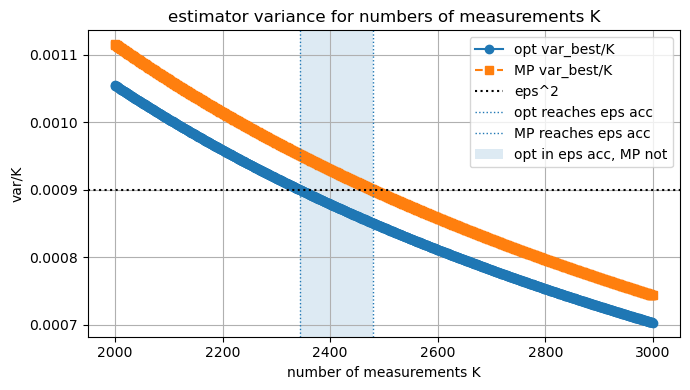

epsilon =  0.03
epsilon^2 =  0.0009
number measurements needed for opt:  2344
number measurements needed for MP:   2479
calculation time: 153.36181300001044


In [255]:
main()